# Extraction and EDA

This notebook goes over the steps taken to perform EDA on the churn dataset and the resulting data cleaning steps that were taken for some columns.

## Setting up imports and having an initial look at the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
churn_df = pd.read_csv("./data/churn.csv", index_col=0, parse_dates=["joining_date"])
churn_df.columns

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

In [3]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   age                           36992 non-null  int64         
 1   gender                        36992 non-null  str           
 2   security_no                   36992 non-null  str           
 3   region_category               31564 non-null  str           
 4   membership_category           36992 non-null  str           
 5   joining_date                  36992 non-null  datetime64[us]
 6   joined_through_referral       36992 non-null  str           
 7   referral_id                   36992 non-null  str           
 8   preferred_offer_types         36704 non-null  str           
 9   medium_of_operation           36992 non-null  str           
 10  internet_option               36992 non-null  str           
 11  last_visit_time               36992 non

Observations:

1. Small-medium sized dataset with around 37k entries.
2. There are many categorical features so we will need to perform EDA separately on the numerical/continuous features and the categorical features.
3. It will be important to compare distribution of each feature across the values in `churn_risk_score` to identify visually from the beginning the any features that will be important in the modelling phase.

## Columns with unclear or no-value add to modelling

These were columns that were identified as not providing much value to the modelling process. The values in these columns are unique alphanumeric codes and they most likely will not help the modelling stage later. These will be discarded later in the modelling stage. 

`referral_id` seems to be a kind of customer ID of some kind and we have no other data that we can use that ID to link to. 

In [4]:
unclear_value_add_columns = ["security_no", "referral_id"]
churn_df[unclear_value_add_columns].sample(10)

,security_no,referral_id
16391,RYNGJN4,CID47069
22725,AOZ5J0P,xxxxxxxx
35604,N5D384S,xxxxxxxx
5600,4FY0ICH,CID6530
23110,PNCT4VO,xxxxxxxx
14989,58I5YDQ,CID42143
7530,G715KII,xxxxxxxx
26520,1E29F9S,xxxxxxxx
7205,NDOTE28,CID44954
17876,FPWHDIU,CID18970


No overlap between the two columns either.

In [5]:
## No overlap between the columns so they don't seem to be related at all
set(churn_df[unclear_value_add_columns[0]].unique()).intersection(set(churn_df[unclear_value_add_columns[1]].unique()))

set()

## Date/Time based columns

There are two date/time columns but the following analysis shows that there are no significant patterns. Additionally, `last_visit_time` seems to just be the time of day and that does not provide much helpful information as it does not hold the date.

It is also unclear when this dataset was generated, but we can assume a dataset creation date as at least the maximum `joining_date`.

In [6]:
date_time_based_columns = ["joining_date", "last_visit_time"]

In [7]:
churn_df_joining_date = churn_df['joining_date'].apply(lambda x: pd.Series([x.year, x.month, x.quarter, x.day, "weekend" if x.weekday() >= 5 else "weekday"]))

# Rename the columns for clarity
churn_df_joining_date.columns = ['year', 'month', 'quarter', 'date', 'weekend']

In [8]:
def plot_categorical_frequency(column: str, data: pd.DataFrame) -> None:
    counts = data[column].value_counts().sort_index()
    counts.plot(kind='bar')

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Frequency of values in "{column}" column')
    plt.tight_layout()
    plt.show()

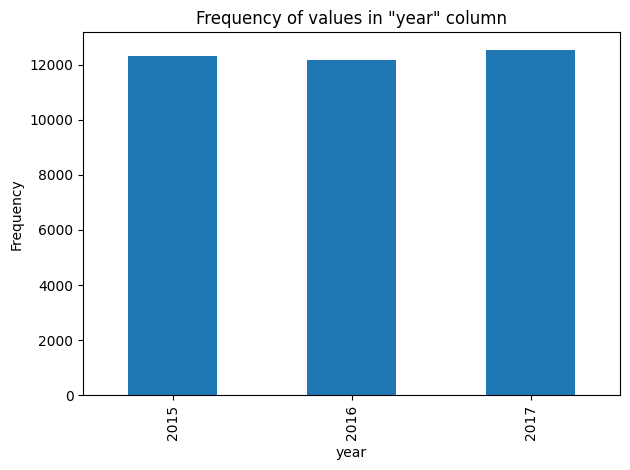

In [9]:
plot_categorical_frequency('year', churn_df_joining_date)

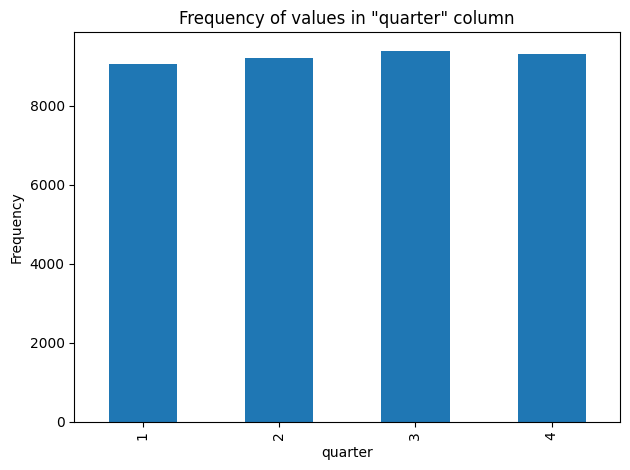

In [10]:
plot_categorical_frequency('quarter', churn_df_joining_date)

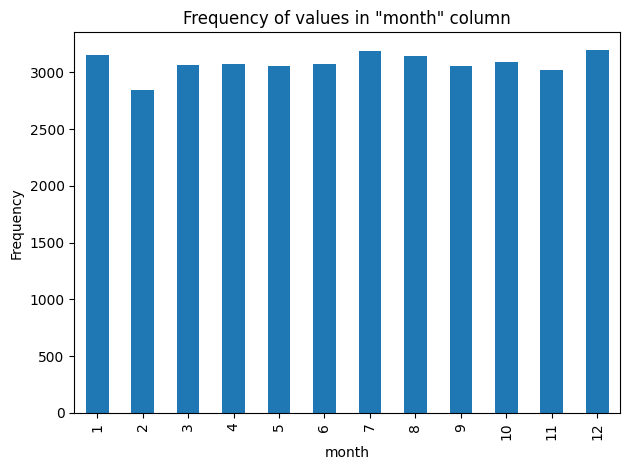

In [11]:
plot_categorical_frequency('month', churn_df_joining_date)

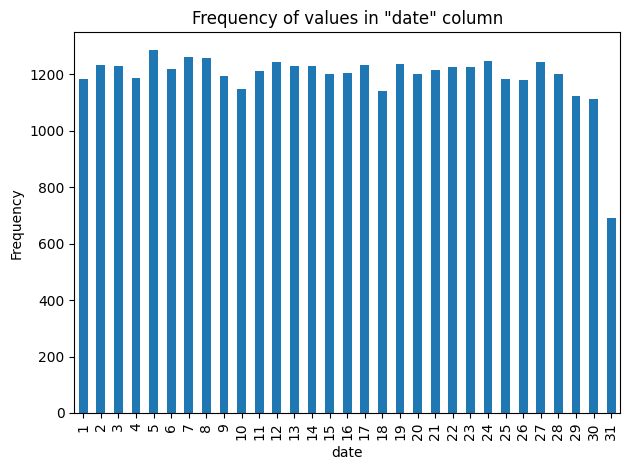

In [12]:
plot_categorical_frequency('date', churn_df_joining_date)

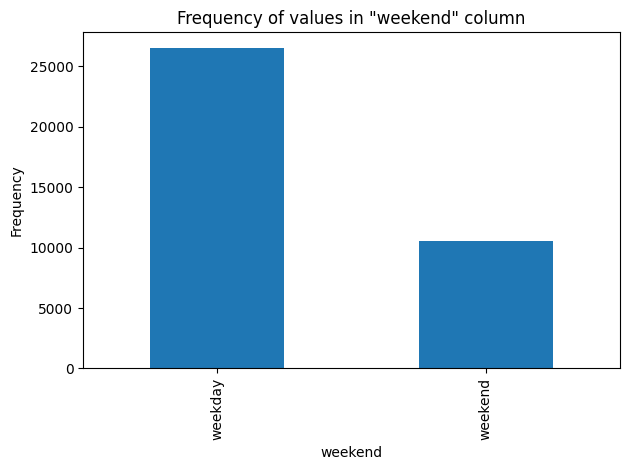

In [13]:
plot_categorical_frequency('weekend', churn_df_joining_date)

## Mixed datatype column

The `avg_frequency_login_days` column has string data types but most of them are numbers. It is mostly numeric but there are some entries that are "Error" codes. This will need to be cleaned up before we can use it for modelling. We will need to convert the strings into `floats` and then perform EDA on the resulting column.

In [14]:
mixed_numerical = ["avg_frequency_login_days"]
churn_df[mixed_numerical].sample(10)

,avg_frequency_login_days
29314,28.0
3093,11.0
35732,40.698282329104586
1182,-6.725075748021094
6949,28.0
28346,1.0
11717,30.989602660083477
3491,10.0
22222,28.0
33092,27.0


In [15]:
import re
float_pattern = r'^[-+]?\d*\.?\d+$'
churn_df["avg_frequency_login_days"] = churn_df["avg_frequency_login_days"].apply(lambda x : float(x) if bool(re.match(float_pattern, x)) else pd.NA)

In [16]:
number_of_na_in_avg_frequency_login_days = sum(churn_df["avg_frequency_login_days"].isna())
print(number_of_na_in_avg_frequency_login_days)

# Replace NA values with mean of the entire column
churn_df["avg_frequency_login_days"] = churn_df["avg_frequency_login_days"].fillna(churn_df["avg_frequency_login_days"].mean())

3522


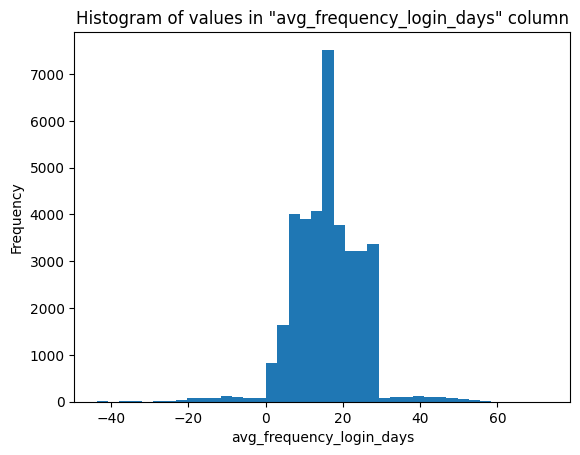

In [17]:
plt.hist(list(churn_df["avg_frequency_login_days"].values), bins=40)
plt.xlabel("avg_frequency_login_days")
plt.ylabel('Frequency')
plt.title(f'Histogram of values in "avg_frequency_login_days" column')
plt.show()

It seems there are some negative values here, so we will replace these values with the absolute value later on.

## Numerical Columns

Columns that have a clear numerical value. As we will see below, some of these have negative values, which are most definitely errors so we will clean them.

In [18]:
numerical_columns = ["days_since_last_login", "avg_time_spent", "avg_transaction_value", "points_in_wallet", "age"]

In [19]:
churn_df[numerical_columns].describe()

,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,age
count,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,-41.915576,243.472334,29271.194003,686.882199,37.118161
std,228.819900,398.289149,19444.806226,194.063624,15.867412
min,-999.000000,-2814.109110,800.460000,-760.661236,10.000000
25%,8.000000,60.102500,14177.540000,616.150000,23.000000
50%,12.000000,161.765000,27554.485000,697.620000,37.000000
75%,16.000000,356.515000,40855.110000,763.950000,51.000000
max,26.000000,3235.578521,99914.050000,2069.069761,64.000000


#### `age`

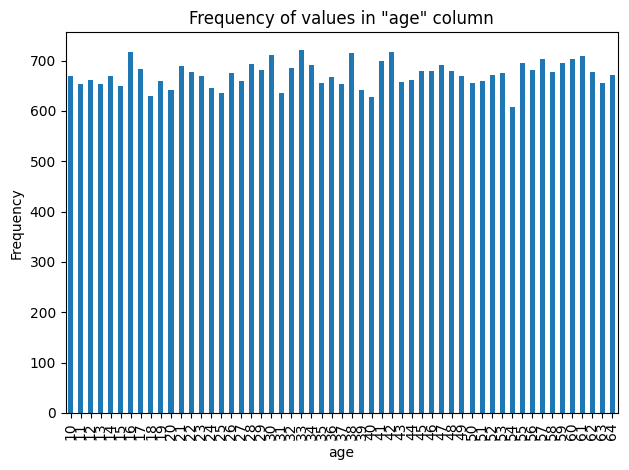

In [19]:
plot_categorical_frequency("age", churn_df)

#### `avg_time_spent`

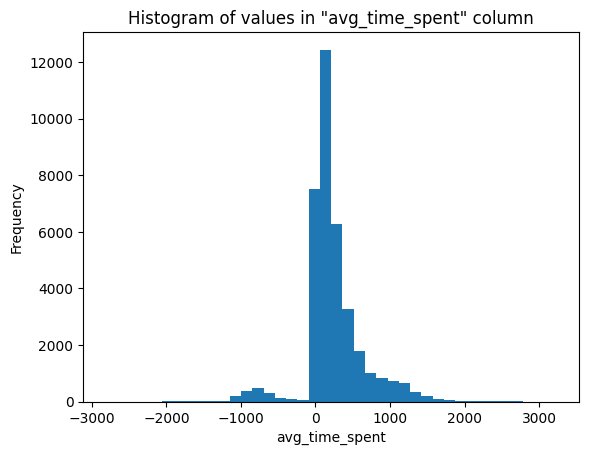

In [18]:
plt.hist(list(churn_df["avg_time_spent"].values), bins=40)
plt.xlabel("avg_time_spent")
plt.ylabel('Frequency')
plt.title(f'Histogram of values in "avg_time_spent" column')
plt.show()

Negative values look like calculation errors - recommended strategy is to replace with absolute value.

#### `avg_transaction_value`

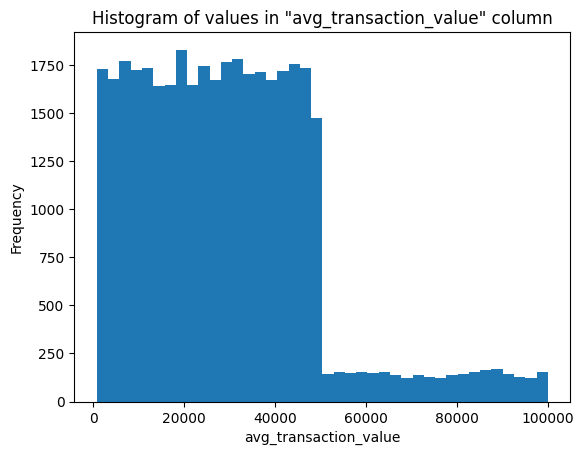

In [20]:
plt.hist(list(churn_df["avg_transaction_value"].values), bins=40)
plt.xlabel("avg_transaction_value")
plt.ylabel('Frequency')
plt.title(f'Histogram of values in "avg_transaction_value" column')
plt.show()

#### `points_in_wallet`

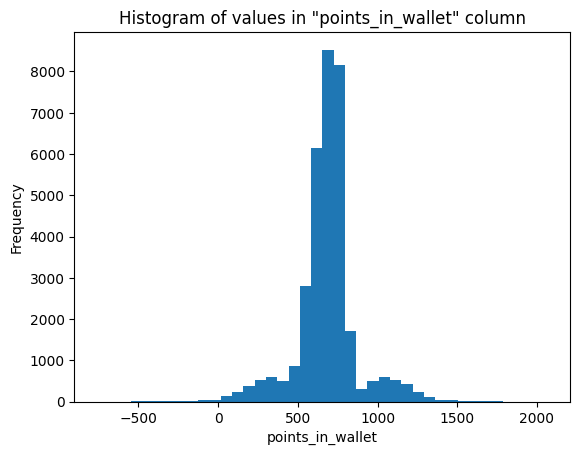

In [21]:
plt.hist(list(churn_df["points_in_wallet"].values), bins=40)
plt.xlabel("points_in_wallet")
plt.ylabel('Frequency')
plt.title(f'Histogram of values in "points_in_wallet" column')
plt.show()

Negative values look like calculation errors - recommended strategy is to replace with absolute value.

#### `days_since_last_login`

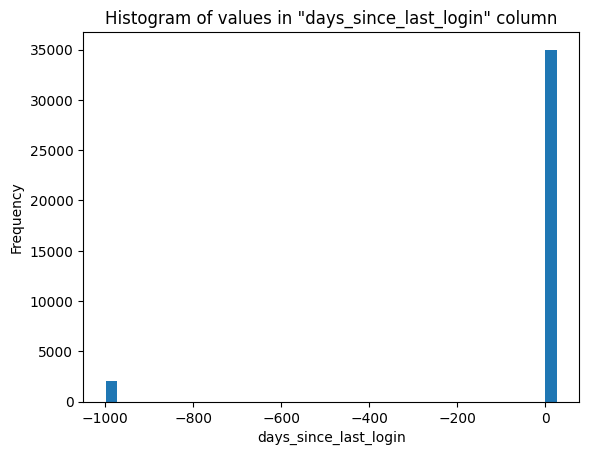

In [22]:
plt.hist(list(churn_df["days_since_last_login"].values), bins=40)
plt.xlabel("days_since_last_login")
plt.ylabel('Frequency')
plt.title(f'Histogram of values in "days_since_last_login" column')
plt.show()

In [24]:
churn_df["days_since_last_login"][churn_df["days_since_last_login"] < 0].value_counts()

days_since_last_login
-999    1999
Name: count, dtype: int64

All the negative values are -999. The recommended strategy is to replace with median as this is most likely an error code.

### Data cleaning

We will clean the data as per the observations made above.

In [25]:
# Replace -999 with median of days_since_last_login
churn_df.loc[churn_df["days_since_last_login"] < 0, "days_since_last_login"] = pd.NA

# Future improvement idea is to change this to +- a few days generated at random, centered at the median (because the distribution suddenly then peaks higher at the median value after this)
churn_df["days_since_last_login"] = churn_df["days_since_last_login"].fillna(churn_df["days_since_last_login"].median())

In [26]:
cols_with_negatives = ['avg_frequency_login_days', 'avg_time_spent', 'points_in_wallet']
for col in cols_with_negatives:
    neg_count = (churn_df[col] < 0).sum()
    print(f"{col} has {neg_count} negative values")

avg_frequency_login_days has 683 negative values
avg_time_spent has 1719 negative values
points_in_wallet has 136 negative values


In [27]:
# Replace with absolute value, values are not as numerous as to change the distribution massively
cols_to_fix = ['avg_frequency_login_days', 'avg_time_spent', 'points_in_wallet']

for col in cols_to_fix:
    churn_df[col] = churn_df[col].abs()

## Visualizing relationship to churn

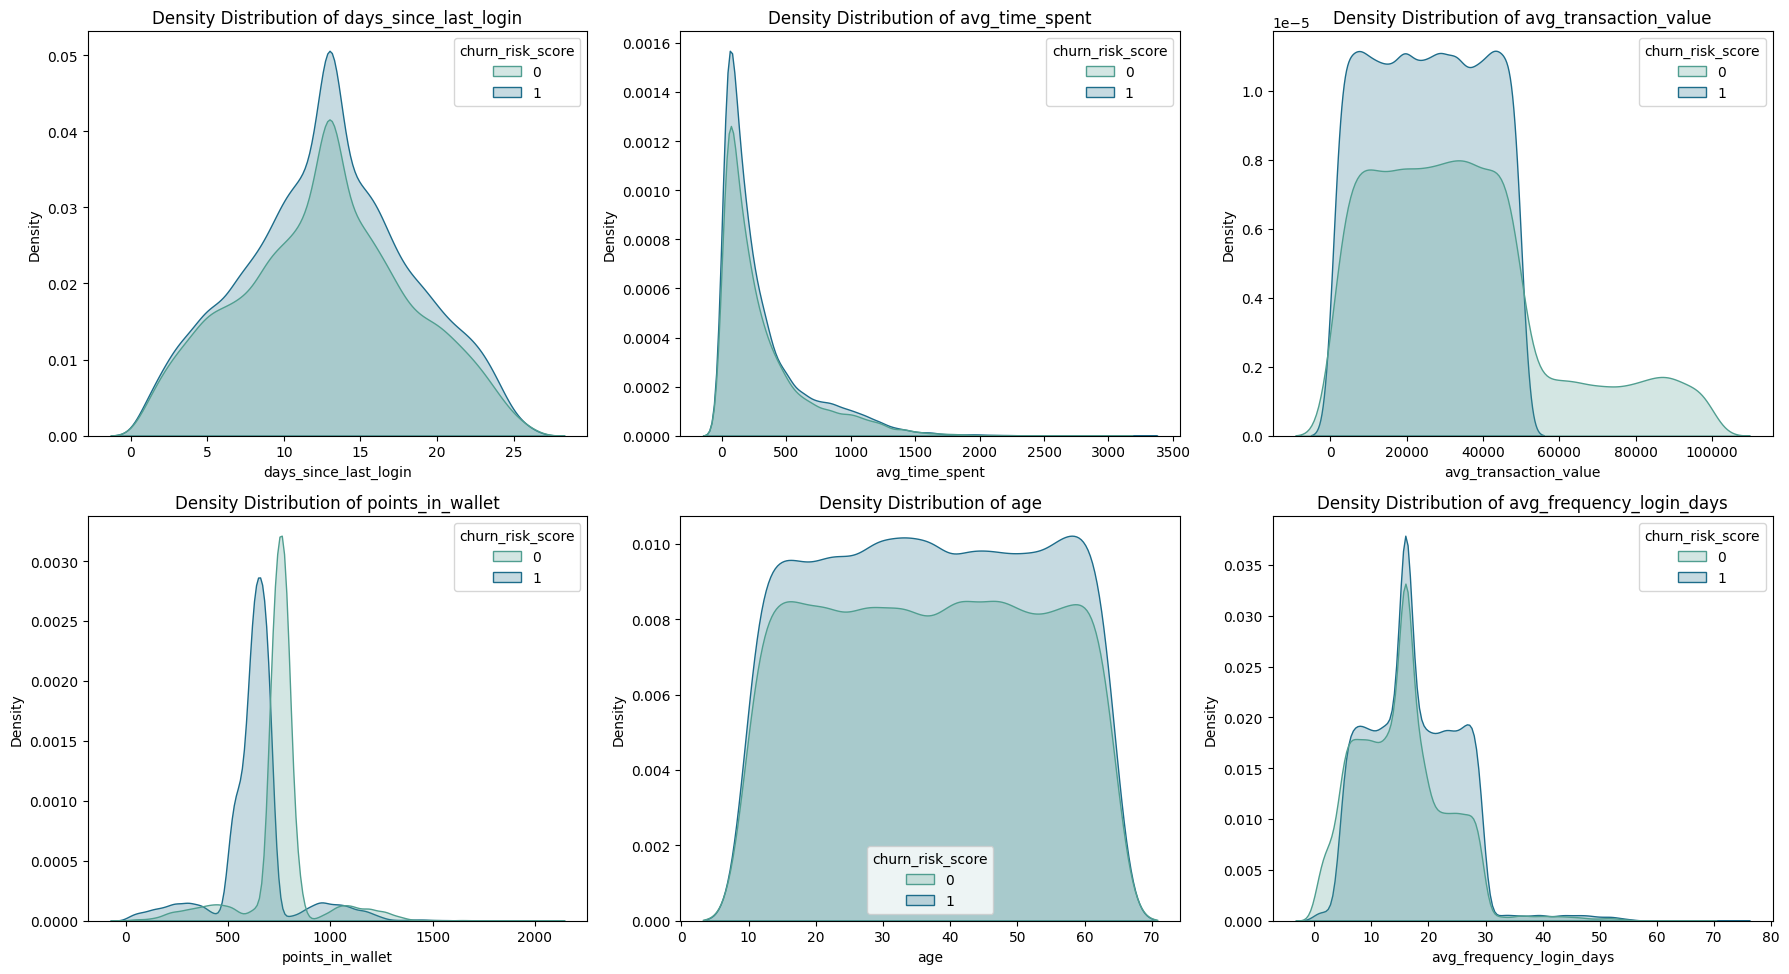

In [28]:
# Updated list of numeric columns
num_cols = ['days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'points_in_wallet', 'age', "avg_frequency_login_days"]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=churn_df, x=col, hue='churn_risk_score', fill=True, ax=axes[i], palette='crest')
    axes[i].set_title(f'Density Distribution of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

1. Interestingly, the KDEs of `days_since_last_login` and `avg_time_spent`, show no separation between churners and non-churners.
2. `avg_transaction_value` and `points_in_wallet` do show a separation between churners and non-churners. Non-churners tend to have higher `points_in_wallet`, and their `avg_transaction_value` also seems to be high.
3. `avg_frequency_login_days` is higher for churners, whereas non-churners tend to be on the lower end.

Point no. 2 indicates that churn may be happening due to the value that the users are able to derive from the app, rather than to do with engagement (like a social media app).


#### Points per dollar spent?

This would be interesting to visualize, because the idea is that if you are a power user, you would be able to derive more points from the system given the same amount of money.

<Axes: xlabel='points_per_dollar', ylabel='Density'>

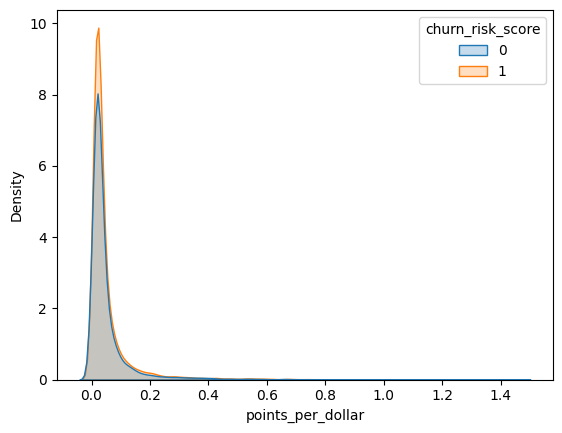

In [29]:
churn_df['points_per_dollar'] = churn_df['points_in_wallet'] / (churn_df['avg_transaction_value'] + 1)
sns.kdeplot(data=churn_df, x='points_per_dollar', hue='churn_risk_score', fill=True)

Observations:

1. If you spend less points per dollar, you are more likely to be a churner than a non-churner.

## All other columns

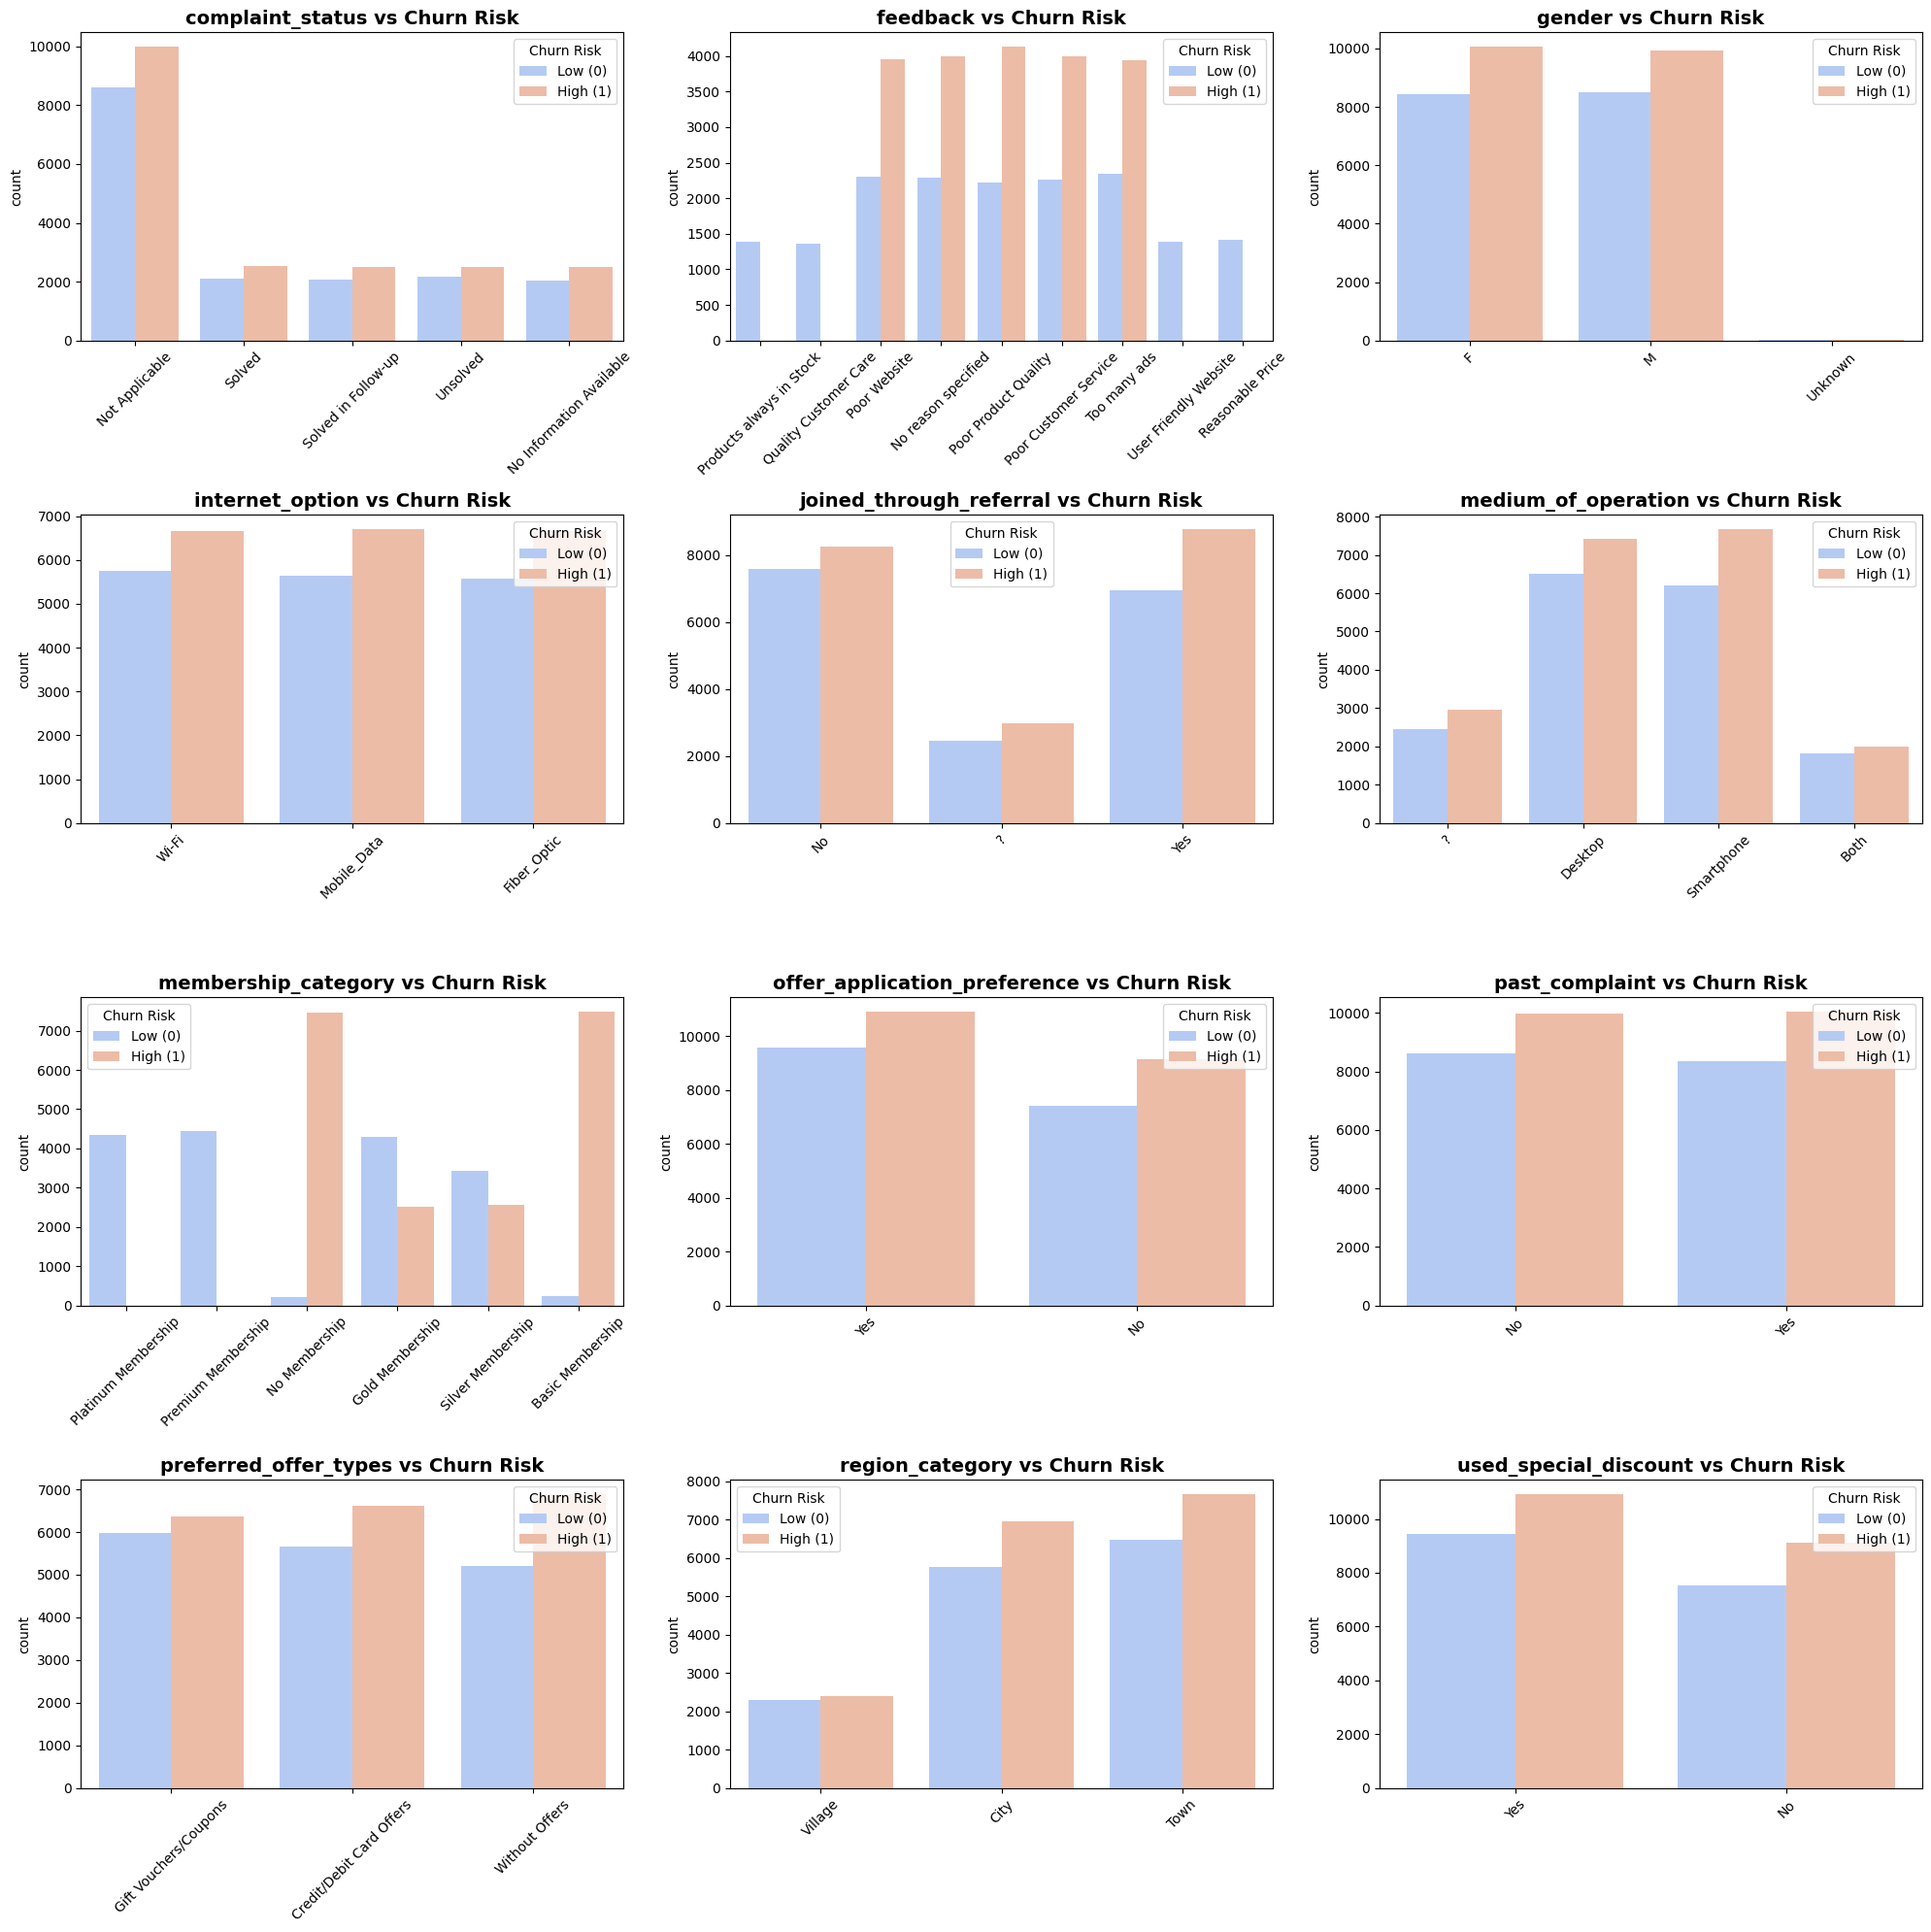

In [30]:
cat_cols = [
    'complaint_status', 'feedback', 'gender', 'internet_option', 
    'joined_through_referral', 'medium_of_operation', 'membership_category', 
    'offer_application_preference', 'past_complaint', 'preferred_offer_types', 
    'region_category', 'used_special_discount'
]

target = 'churn_risk_score'

# Define grid
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Plotting count with target hue
    sns.countplot(data=churn_df, x=col, hue=target, ax=axes[i], palette='coolwarm')
    
    axes[i].set_title(f'{col} vs Churn Risk', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn Risk', labels=['Low (0)', 'High (1)'])

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

1. Except for two features, across all other categorical features, churn risk is split evenly between class labels.
2. The labels of the `membership_category` and `feedback` features can however be used to infer the `churn_risk_score` and so these will most likely be useful features during the modelling stage.
3. Interestingly, the complaint status does not seem to have any bearing on the `churn_risk_score`.

From the above plots however, the raw counts may not show the full picture and if we look at proportions, that may provide a better idea of the relationship between `churn_risk_score` and the categorical features.

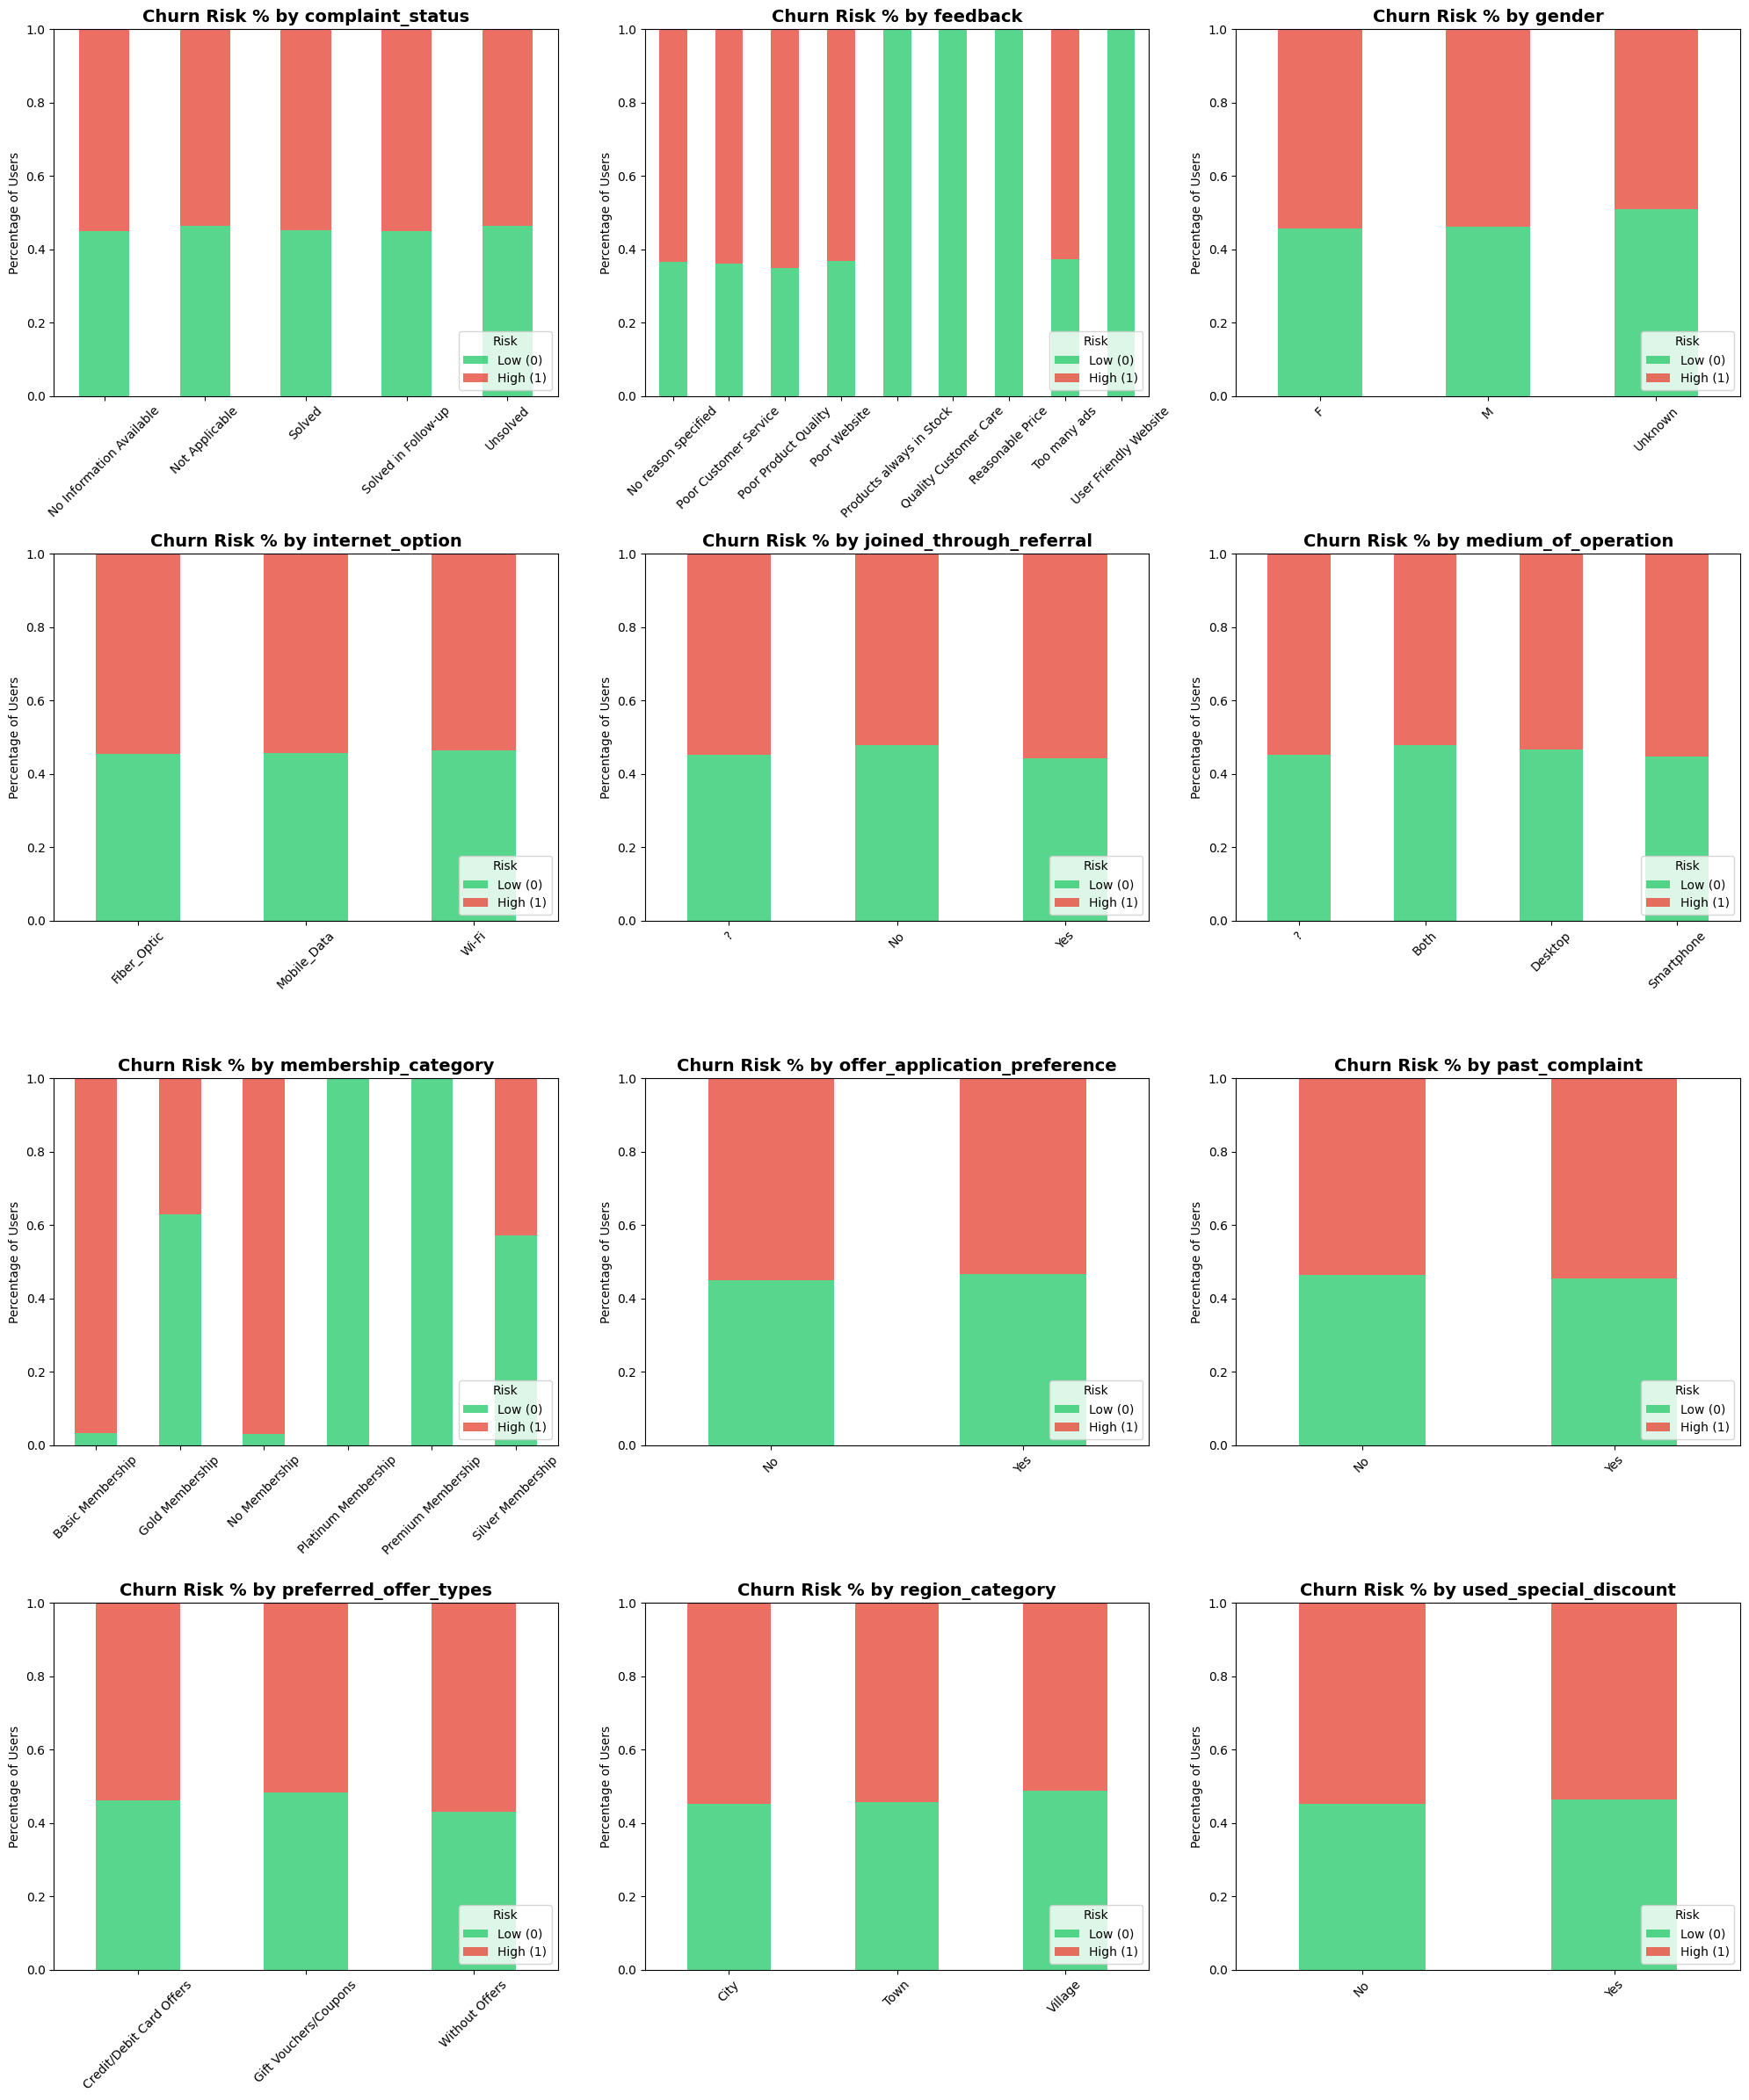

In [31]:
# Grid setup
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 1. Create a cross-tabulation and normalize by row (index)
    # This turns counts into percentages that sum to 1.0 (100%)
    cross_tab = pd.crosstab(churn_df[col], churn_df[target], normalize='index')
    
    # 2. Plot as a stacked bar chart
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8)
    
    axes[i].set_title(f'Churn Risk % by {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Percentage of Users')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1) # Force 0 to 100% scale
    axes[i].legend(title='Risk', labels=['Low (0)', 'High (1)'], loc='lower right')
    axes[i].tick_params(axis='x', rotation=45)

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We see that the same patterns are observed as before.

## Conclusions

Membership tiers are strong indicators of churn risk, and also the feedback, negative feedback being a good indicator of churn.

Additionally, `avg_transaction_value` and `points_in_wallet` do show a separation between churners and non-churners. Non-churners tend to have higher `points_in_wallet`, and their `avg_transaction_value` also seems to be high.

Putting together the analysis of the categorical and continuous features, it seems that churn may be happening due to the value that the users are able to derive from the service, rather than to do with engagement (like a social media app). This is because engagement metrics such as time spent or frequency of login do not seem to be strong signals for churn.

### Unclear points

It is unclear how this data was collected from a timeline perspective. With the `churn_risk_score` being 0 or 1, is feedback collected after churn has occurred? And what does risk being 0 or 1 mean? Is it recording a churn event or a rounding up a probability?

We can do a bit of analysis for that by checking if non-churners also give negative feedback. If they do, that could mean that negative feedback isn't **only** collected at exit from the app.

In [32]:
# Check how many 'Risk 0' people actually give negative feedback
mismatch = churn_df[(churn_df['churn_risk_score'] == 0) & (churn_df['feedback'].str.contains('Poor|No|Too', na=False))]
print(f"Users with bad feedback who haven't churned: {len(mismatch)}")

Users with bad feedback who haven't churned: 11430


This leads us to believe that the feedback may be cautiously used in the modelling because it isn't something that is only collected at the moment of churn. It may also be collected while the user is still active. However, it is very likely that negative feedback is collected when the user exits the app (for example uninstalling the app).

## Assumptions and limitations

1. We can assume that feedback is provided throughout the usage of the app, and that negative feedback is not provided only at exit from the app. 
2. It is **not** reasonable to assume that the categorical features are independent, and for the time being this a limitation of the current approach with this analysis/dataset. In the next iteration of this analysis, this will be corrected.
3. We are also making an assumption that the latest joining date is somewhat representative of the time that this dataset was collected.


## Adding some more features for modelling

We can also add another few features for the purposes of modelling and those are the `tenure` or how long a user has been on the platform, and the `value_per_login` which could be used to represent how much they spend each time they login.

In [33]:
# Convert Joining Date to Tenure (Days)
# Use the latest date in the set as the "reference" point
ref_date = churn_df['joining_date'].max() 
churn_df['tenure_days'] = (ref_date - churn_df['joining_date']).dt.days

# Value per Login
# If they login a lot but spend little, they are "Window Shoppers" (High Risk)
churn_df['value_per_login'] = churn_df['avg_transaction_value'] / (churn_df['avg_frequency_login_days'] + 1)

## Write dataset to disk for next stages

In [34]:
churn_df.to_csv("./data/cleaned_churn_data.csv")